# Cross-dataset label transfer using CellTypist

### Load reference and test datasets

In [1]:
import scanpy as sc
import celltypist
import time
import numpy as np
import pandas as pd
import anndata
from scipy.io import mmread

In [2]:
# BUILDING TEST DATA
filename = '/ibex/user/sotoorda/masterh1/LLM project/CellTypist/Objects/xpand_matrix.mtx'
X = mmread(filename)
metadata = pd.read_csv('/ibex/user/sotoorda/masterh1/LLM project/CellTypist/Objects/xpand_metadata.csv')
# Opening and formating the gene names
with open('/ibex/user/sotoorda/masterh1/LLM project/CellTypist/Objects/xpand_gene_names.csv', 'r') as f:
    genes = f.read().splitlines()

# Building the anndata object
data_test = anndata.AnnData(X = X.transpose().tocsr())
data_test.obs = metadata
data_test.var.index = genes
data_test.obs.index = data_test.obs['barcode']

# BUILD REFERENCE DATA
filename = '/ibex/user/sotoorda/masterh1/LLM project/CellTypist/Objects/hca_ref_matrix.mtx'
X = mmread(filename)
metadata = pd.read_csv('/ibex/user/sotoorda/masterh1/LLM project/CellTypist/Objects/hca_ref_metadata.csv')
# Opening and formating the gene names
with open('/ibex/user/sotoorda/masterh1/LLM project/CellTypist/Objects/hca_ref_gene_names.csv', 'r') as f:
    genes = f.read().splitlines()

# Building the anndata object
data_ref = anndata.AnnData(X = X.transpose().tocsr())
data_ref.obs = metadata
data_ref.var.index = genes
data_ref.obs.index = data_ref.obs['barcode']

### Normalize the datasets

In [3]:
sc.pp.normalize_total(data_test, target_sum = 1e4)
sc.pp.log1p(data_test)
sc.pp.normalize_total(data_ref, target_sum = 1e4)
sc.pp.log1p(data_ref)

## Transfer cell type labels from the first dataset to the second dataset

In [4]:
# Use `celltypist.train` to quickly train a rough CellTypist model.
t_start = time.time()
model_fs = celltypist.train(data_ref, 'CellType', n_jobs = 10, max_iter = 5, use_SGD = True, feature_selection = True, top_genes = 300)
t_end = time.time()
print(f"Time elapsed: {t_end - t_start} seconds")

🍳 Preparing data before training
✂️ 11 non-expressed genes are filtered out
🔬 Input data has 101587 cells and 14110 genes
⚖️ Scaling input data
🏋️ Training data using SGD logistic regression
⚠️ Warning: it may take a long time to train this dataset with 101587 cells and 14110 genes, try to downsample cells and/or restrict genes to a subset (e.g., hvgs)
🔎 Selecting features
🧬 3322 features are selected
🏋️ Starting the second round of training
🏋️ Training data using SGD logistic regression
✅ Model training done!


Time elapsed: 552.7854936122894 seconds


It takes 5 minutes to train this dataset with 33k genes and 134 cell types from 55k cells. Note you can increase `max_iter` to get a more accurate model at the expense of increased runtime.

This model is trained from all genes with only five epochs, and thus is not accurate enough for cell type prediction. But the information about genes can be utilised. Here, we drew top 100 important genes from each cell type as ranked by their absolute regression coefficients associated with the given cell type. For datasets with only several cell types, you may want to increase the top gene number from 100 to for example 300 in order to get a sufficient number of genes for final use.

In [5]:
gene_index = np.argpartition(np.abs(model_fs.classifier.coef_), -100, axis = 1)[:, -100:]
gene_index

array([[1713, 2669, 1377, ..., 2535, 3164, 2706],
       [1758,  383, 3215, ..., 3206, 2001, 2802],
       [2199,  841,  651, ...,  254, 1003, 2888],
       ...,
       [ 517, 3122, 1842, ...,  927, 3124, 1949],
       [3242,  888, 2053, ..., 3209, 3200, 2001],
       [ 153, 1101, 1815, ..., 3266, 2808,  388]])

We next combine/union these genes across cell types.

In [6]:
gene_index = np.unique(gene_index)

These genes will be used for downstream model training.

In [8]:
print(f"Number of genes selected: {len(gene_index)}")

Number of genes selected: 1334


### Model training and label transfer

With the downsampled cells (55k) and selected features (5k), we next train `adata_Elmentaite` using [celltypist.train](https://celltypist.readthedocs.io/en/latest/celltypist.train.html).

To allow for unbiased probability estimates, here we used the non-SGD version of CellTypist training (i.e. a traditional logistic regression framework).

In [7]:
# Add `check_expression = False` to bypass expression check with only a subset of genes.
t_start = time.time()
model = celltypist.train(data_ref[:, gene_index], 'CellType', check_expression = False, n_jobs = 10, max_iter = 100)
t_end = time.time()
print(f"Time elapsed: {(t_end - t_start)/60} minutes")

🍳 Preparing data before training
✂️ 3 non-expressed genes are filtered out
🔬 Input data has 101587 cells and 1331 genes
⚖️ Scaling input data
🏋️ Training data using logistic regression


✅ Model training done!


Time elapsed: 8.977290101846059 minutes


In [8]:
# Save the model.
model.write('/ibex/user/sotoorda/masterh1/LLM project/CellTypist/Objects/celltypist_model.pkl')

In [4]:
# Load the model.
model = celltypist.models.Model.load('/ibex/user/sotoorda/masterh1/LLM project/CellTypist/Objects/celltypist_model.pkl')

Using celltypist.annotate to predict `data_test` using the model.

In [5]:
# CellTypist prediction without over-clustering and majority-voting.
t_start = time.time()
predictions = celltypist.annotate(data_test, model = '/ibex/user/sotoorda/masterh1/LLM project/CellTypist/Objects/celltypist_model.pkl')
t_end = time.time()
print(f"Time elapsed: {t_end - t_start} seconds")

🔬 Input data has 23466 cells and 14170 genes
🔗 Matching reference genes in the model
🧬 1331 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!


Time elapsed: 0.9846231937408447 seconds


Using majority vote

In [6]:
# CellTypist prediction with over-clustering and majority-voting.
t_start = time.time()
predictions = celltypist.annotate(data_test, model = '/ibex/user/sotoorda/masterh1/LLM project/CellTypist/Objects/celltypist_model.pkl', majority_voting = True)
t_end = time.time()
print(f"Time elapsed: {t_end - t_start} seconds")

🔬 Input data has 23466 cells and 14170 genes
🔗 Matching reference genes in the model
🧬 1331 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Can not detect a neighborhood graph, will construct one before the over-clustering
/ibex/user/sotoorda/conda-environments/test_env/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
⛓️ Over-clustering input data with resolution set to 15
🗳️ Majority voting the predictions
✅ Majority voting done!


Time elapsed: 37.0905499458313 seconds


It takes 22 seconds to both predict and majority-vote a dataset of 42k cells and 19k genes.

The results include both predicted cell type labels (`predicted_labels`), over-clustering result (`over_clustering`), and predicted labels after majority voting in local subclusters (`majority_voting`). Note in the `predicted_labels`, each query cell gets its inferred label by choosing the most probable cell type among all possible cell types in the given model.

In [11]:
predictions.predicted_labels

,predicted_labels,over_clustering,majority_voting
barcode,,,
_MO291_AAACAGCCACCACAAC-1,pre-PC,0,pre-PC
_MO291_AAACAGCCATCCATCT-1,MPP,5,HSC
_MO291_AAACATGCACCGTTCC-1,MPP,6,Plasma Cell
_MO291_AAACATGCAGCGCTTG-1,pre-PC,3,pre-PC
_MO291_AAACATGCAGGTATTT-1,Plasma Cell,0,pre-PC
...,...,...,...
_MO298_TTTGTGAAGGTATTGC-1,CLP,62,pre-PC
_MO298_TTTGTGGCAGGCGAGT-1,Plasma Cell,6,Plasma Cell
_MO298_TTTGTGTTCGCCTGTT-1,pre-PC,72,pre-PC


In [12]:
# Full probability matrix
prob_matrix = predictions.probability_matrix

# Check if indices are aligned
is_aligned = np.array_equal(prob_matrix.index.values, data_test.obs.index.values)
print(is_aligned)
is_aligned = np.array_equal(predictions.predicted_labels.index.values, data_test.obs.index.values)
print(is_aligned)

# Transfer cell id and ground truth labels to the probability matrix
prob_matrix['Cell_id'] = data_test.obs.index
prob_matrix['Ground_truth'] = data_test.obs['CellType']
prob_matrix['Predicted_label'] = predictions.predicted_labels['predicted_labels']

True
True


In [13]:
# save probability matrix to csv
prob_matrix.to_csv('/ibex/user/sotoorda/masterh1/LLM project/CellTypist/predictions_celltypist.csv', index = False)

,CD8 T-cell,CLP,Dendritic Cell,ERP,Early-Erythroblast,Eo/B/Mast,Eosinophil,Erythroblast,Follicular B cell,GMP,...,Platelet,Pre-Dendritic,PreB,ProB,Stromal,pre-PC,pre-T,Cell_id,Ground_truth,Predicted_label
barcode,,,,,,,,,,,,,,,,,,,,,
_MO291_AAACAGCCACCACAAC-1,1.620859e-01,0.017999,2.919620e-07,2.863908e-17,5.626229e-13,3.765383e-10,1.332063e-07,4.058170e-04,1.313426e-07,3.061519e-13,...,0.001219,1.326860e-12,3.801723e-05,2.320683e-03,1.045129e-05,9.969588e-01,4.805065e-09,_MO291_AAACAGCCACCACAAC-1,ProB,pre-PC
_MO291_AAACAGCCATCCATCT-1,3.332435e-11,0.000315,3.544714e-06,1.097134e-16,8.733247e-19,1.031272e-09,7.368784e-06,6.024277e-10,1.632874e-11,3.623865e-15,...,0.000009,4.649683e-10,3.309665e-16,3.289342e-08,8.821555e-07,3.071226e-06,2.295501e-09,_MO291_AAACAGCCATCCATCT-1,HSC,MPP
_MO291_AAACATGCACCGTTCC-1,1.311882e-10,0.000001,1.312654e-15,2.466051e-10,2.546310e-16,1.236726e-07,6.807440e-03,3.992016e-08,9.472795e-13,3.283617e-10,...,0.001568,5.544606e-10,2.723691e-09,1.078901e-04,4.033359e-04,3.526659e-07,6.690167e-08,_MO291_AAACATGCACCGTTCC-1,GMP,MPP
_MO291_AAACATGCAGCGCTTG-1,2.724513e-05,0.062142,5.892451e-07,1.585503e-16,4.469069e-19,9.637992e-13,5.218542e-09,1.104471e-03,1.431434e-07,2.072730e-16,...,0.000191,1.123236e-07,1.796346e-07,8.560894e-01,9.825192e-05,9.999999e-01,1.155870e-12,_MO291_AAACATGCAGCGCTTG-1,ProB,pre-PC
_MO291_AAACATGCAGGTATTT-1,6.292467e-02,0.050576,1.334557e-05,3.109827e-12,2.519475e-15,8.009298e-07,3.090460e-04,6.038518e-04,1.967560e-08,1.718835e-06,...,0.000132,3.382218e-09,4.900397e-07,5.382611e-05,5.918675e-04,7.089392e-01,1.196907e-08,_MO291_AAACATGCAGGTATTT-1,ProB,Plasma Cell
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
_MO298_TTTGTGAAGGTATTGC-1,1.453505e-03,0.996894,3.249327e-09,1.451138e-11,2.034203e-16,2.086400e-07,6.012353e-06,3.136503e-03,1.464930e-07,1.230331e-13,...,0.005744,1.070194e-09,6.534799e-05,7.990369e-03,1.841418e-04,9.709808e-01,8.099947e-10,_MO298_TTTGTGAAGGTATTGC-1,ProB,CLP
_MO298_TTTGTGGCAGGCGAGT-1,5.660382e-07,0.000667,2.154395e-10,7.216253e-13,1.225316e-16,6.133074e-06,2.523834e-05,1.060997e-05,2.223158e-10,6.451249e-10,...,0.000055,6.094121e-08,1.480097e-08,1.929302e-08,1.254962e-06,6.380222e-05,2.784182e-12,_MO298_TTTGTGGCAGGCGAGT-1,GMP,Plasma Cell
_MO298_TTTGTGTTCGCCTGTT-1,8.994073e-05,0.000060,6.897575e-12,1.139615e-14,8.621064e-12,1.033809e-07,3.999252e-04,8.207200e-07,2.312265e-06,2.651898e-10,...,0.000004,8.693385e-12,1.069928e-05,3.743424e-02,2.124352e-05,9.987601e-01,1.518961e-10,_MO298_TTTGTGTTCGCCTGTT-1,ProB,pre-PC


Visualise the correspondence between this prediction result and the ground-truth cell types (`cell_type` in `adata_James.obs`) using [celltypist.dotplot](https://celltypist.readthedocs.io/en/latest/celltypist.dotplot.html).

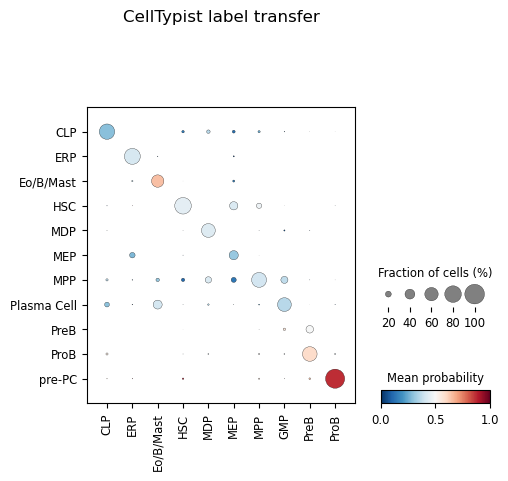

In [13]:
# You can also change the value of `use_as_prediction` to `predicted_labels` to compare the raw prediction result with the pre-defined cell types.
celltypist.dotplot(predictions, use_as_reference = 'CellType', use_as_prediction = 'majority_voting')

For each cell type in `adata_James` (column), this plot shows how it can be 'decomposed' into different cell types predicted by the CellTypist model from `adata_Elmentaite` (rows).

Transform the prediction result into an `AnnData`.

In [14]:
# Get an `AnnData` with predicted labels embedded into the cell metadata columns.
adata = predictions.to_adata()

Compared to `adata_James`, the new `adata` has additional prediction information in `adata.obs` (`predicted_labels`, `over_clustering`, `majority_voting` and `conf_score`). Of note, all these columns can be prefixed with a specific string by setting `prefix` in [to_adata](https://celltypist.readthedocs.io/en/latest/celltypist.classifier.AnnotationResult.html#celltypist.classifier.AnnotationResult.to_adata).

In [15]:
adata.obs.iloc[:, -4:]

,predicted_labels,over_clustering,majority_voting,conf_score
barcode,,,,
_MO291_AAACAGCCACCACAAC-1,pre-PC,0,pre-PC,1.000000
_MO291_AAACAGCCATCCATCT-1,HSC,5,HSC,0.123970
_MO291_AAACATGCACCGTTCC-1,Plasma Cell,6,Plasma Cell,0.999990
_MO291_AAACATGCAGCGCTTG-1,pre-PC,3,pre-PC,0.996292
_MO291_AAACATGCAGGTATTT-1,pre-PC,0,pre-PC,0.999981
...,...,...,...,...
_MO298_TTTGTGAAGGTATTGC-1,ProB,62,pre-PC,0.126188
_MO298_TTTGTGGCAGGCGAGT-1,Plasma Cell,6,Plasma Cell,0.999078
_MO298_TTTGTGTTCGCCTGTT-1,pre-PC,72,pre-PC,1.000000


Visually compare the original cell type annotations with the CellTypist predictions.